# Sota solvers and pruning techniques

In [170]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra
from utilities import TestFunctions, Utils

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Importing and using the new graph

We use a 5x5 grid network, 25 nodes in total

In [4]:
sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

In [5]:
matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

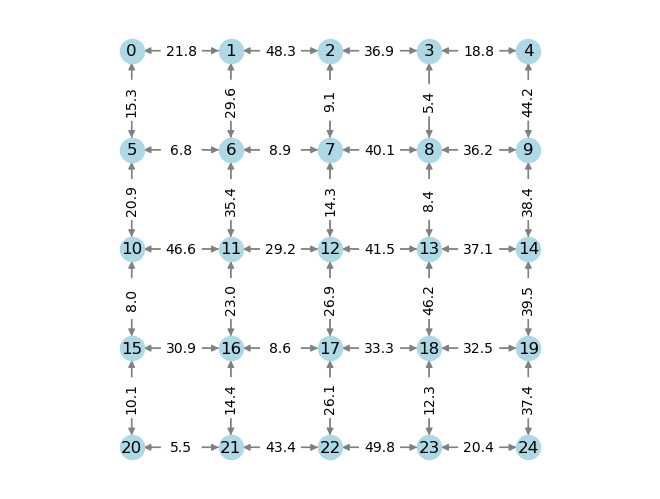

In [5]:
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
graph.print_graph(grid_shape=(5,5))

## Algorithms usage

In [7]:
destination_node = 20
time_budget = 300

### StandardSOTA

In [12]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

In [13]:
sota = StandardSOTASolver(graph, destination_node, time_budget)
sota.solve();

Convergence reached!
End of iterations


In [14]:
sota.print_sota_matrix()
sota.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  5  5  5]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  7  7]
 ...
 [-1 -1 -1 ... 17 17 17]
 [-1 -1 -1 ... 22 22 22]
 [-1 -1 -1 ... 23 23 23]]


In [15]:
sota.extract_path(3)

[3, 2, 7, 12, 17, 16, 15, 20]

### SingleIteration SOTA

In [24]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
sota2 = SingleIterationSOTASolver(graph, destination_node, time_budget)

In [25]:
sota2.solve()
sota2.print_sota_matrix()
sota2.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  1  5  1]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  1  1]
 ...
 [-1 -1 -1 ... 21 21 21]
 [-1 -1 -1 ... 22 22 22]
 [-1 -1 -1 ... 23 23 23]]


In [26]:
sota2.extract_path(3)

[3, 2, 1, 6, 11, 10, 15, 20]

### Precomputing techniques: Reach

#### Brute-force Reach

In [9]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)
r = bfReach(graph, s)

In [10]:
r.reach_computation()

Computing reach values...
Reach values computed


array([12.37980199, 26.83374876, 46.02069332, 22.98661169, 13.86546712,
       22.37756144, 38.92577814, 30.63261947, 22.98661169, 27.9620986 ,
       41.52696536, 46.35191484, 41.98914855, 28.87747902, 30.77064295,
       36.23485462, 29.35568179, 40.79085084, 27.42530996, 37.35451841,
       19.92644511, 12.58028783, 15.09970989, 30.88100423,  0.        ])

In [11]:
r.reach_pruning()

Pruning nodes...
Pruned nodes: {24, 1}


{1, 24}

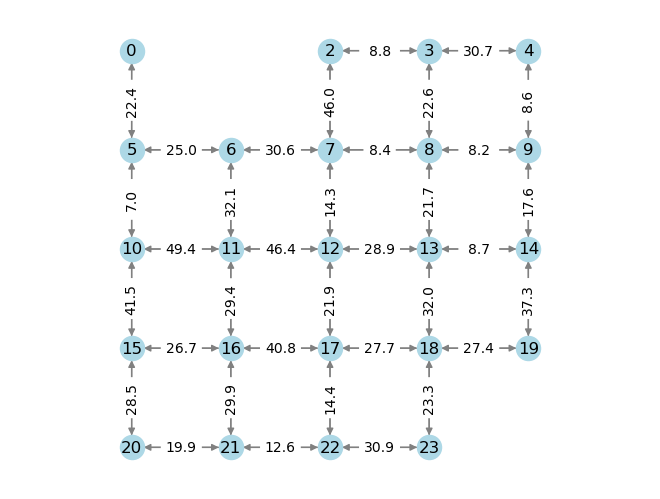

In [12]:
graph.print_graph()

#### Deterministic Reach

In [16]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
r = detReach(graph, d, destination_node)

In [17]:
r.reach_computation()

Computing reach values...
Reach values computed


array([ 6.73367004, 31.98854853, 31.98854853, 14.50807646,  6.78618332,
       16.09098533, 44.96274222, 22.61991775, 41.37786347, 32.78011589,
        8.00350687, 26.84331131, 32.59374031, 14.50115939, 22.4775472 ,
       22.81311843, 21.35970826, 32.59374031, 19.4677743 , 21.65711624,
        0.        , 15.29164821, 25.04698949, 43.05831705,  0.        ])

In [18]:
r.reach_pruning()

Pruning nodes...
Pruned nodes: {1, 3, 4, 11, 13, 16, 19, 22, 24}


{1, 3, 4, 11, 13, 16, 19, 22, 24}

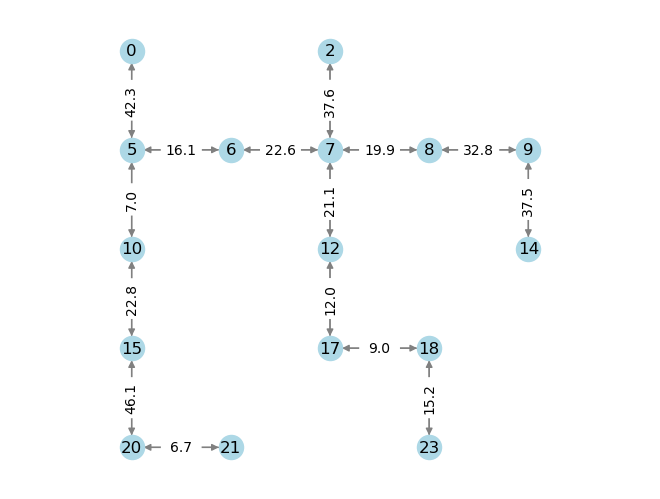

In [19]:
graph.print_graph()

### Precomputing techniques: Arc-flags

#### Brute-force Arc-flags

In [28]:
adj_matrix, var_matrix = matrix.compute_matrices()

In [29]:
adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)
f = bfArcFlags(graph, 4, s)

In [30]:
f.arcflags_computation()


Executing partition...
Partitioning of the graph in 4 regions executed in 0.0184 seconds!
Computing arcflags...
Arcflags computed!


{(np.int64(0), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(0), np.int64(5)): {0: True, 1: True, 2: False, 3: False},
 (np.int64(1), np.int64(0)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(1), np.int64(2)): {0: True, 1: False, 2: True, 3: False},
 (np.int64(1), np.int64(6)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(3)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(2), np.int64(7)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(3), np.int64(2)): {0: True, 1: True, 2: True, 3: False},
 (np.int64(3), np.int64(4)): {0: True, 1: False, 2: False, 3: True},
 (np.int64(3), np.int64(8)): {0: True, 1: False, 2: True, 3: True},
 (np.int64(4), np.int64(3)): {0: True, 1: True, 2: True, 3: False},
 (np.int64(4), np.int64(9)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(5), np.int64(0)): {0: True, 1: False, 2: True, 3: False},
 (np.int64(5), np.int64(6)): {0: True, 1:

In [31]:
f.arcflags_pruning()

Pruning edges...
[ArcFlags] Pruned 44 edges for destination 20 (region 1).


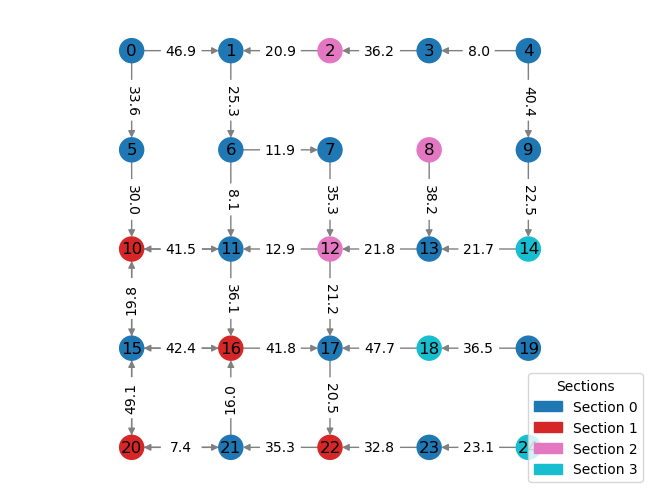

In [32]:
f.print_graph_sections()

#### Deterministic Arc-flags

In [33]:
adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, 4, d, destination_node)

In [34]:
f.arcflags_computation()

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0188 seconds!
Computing arcflags...
Arcflags computed!


{(np.int64(0), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(0), np.int64(5)): {0: True, 1: True, 2: False, 3: False},
 (np.int64(1), np.int64(0)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(1), np.int64(2)): {0: False, 1: False, 2: True, 3: False},
 (np.int64(1), np.int64(6)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(1)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(3)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(2), np.int64(7)): {0: True, 1: False, 2: True, 3: True},
 (np.int64(3), np.int64(2)): {0: True, 1: False, 2: True, 3: False},
 (np.int64(3), np.int64(4)): {0: True, 1: False, 2: False, 3: True},
 (np.int64(3), np.int64(8)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(4), np.int64(3)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(4), np.int64(9)): {0: True, 1: False, 2: False, 3: True},
 (np.int64(5), np.int64(0)): {0: True, 1: False, 2: False, 3: False},
 (np.int64(5), np.int64(6)): {0: True, 1:

In [35]:
f.arcflags_pruning()

Pruning edges...
[ArcFlags] Pruned 36 edges for destination 20 (region 1).


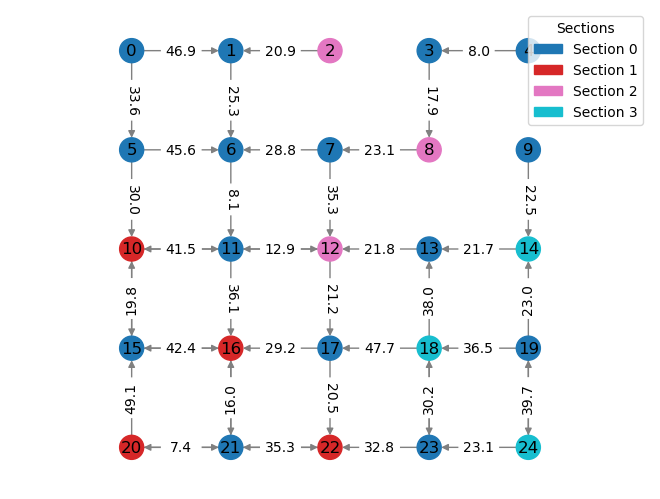

In [36]:
f.print_graph_sections()

## Query times comparisons

Time-comparisons between one simple use case on a 5x5 graph.

In [55]:
matrix = Matrix(10, 10)
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

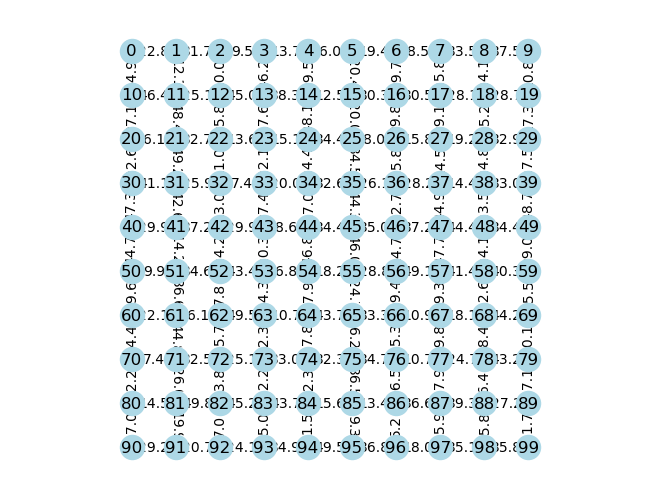

In [40]:
graph.print_graph()

In [81]:
# standard sota solver

import time

destination_node = 72
time_budget = 900

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

s = StandardSOTASolver(graph, destination_node, time_budget)

start = time.time()
s.solve()
end = time.time()

print(f"Policy computed on {end-start:.4f} seconds")

print("policy last column:")
print(s.get_policy_matrix()[:, -1])

print("sota last column:")
print(s.get_sota_matrix()[:, -1])


Policy computed on 5332.4326 seconds
policy last column:
[10 11 12 13 14 15  5  6  7  8 11 21 22 23 24 14 26 27 17 18 21 31 32 33
 34 24 36 37 27 28 31 41 42 32 44 34 46 47 48 38 50 51 52 53 54 55 56 57
 47 48 51 61 62 52 64 65 66 56 68 58 61 71 72 73 63 64 65 66 67 68 71 72
 -1 72 73 74 75 76 77 78 70 71 72 73 83 84 85 86 87 88 91 81 82 92 84 94
 95 87 97 98]
sota last column:
[8.10216563e-07 3.84312539e-06 5.18945080e-06 2.03237262e-06
 6.13156573e-07 1.84611259e-07 7.14696932e-08 1.84110107e-08
 3.65609305e-09 7.08228595e-10 4.07928472e-06 1.85088468e-05
 2.13406084e-05 1.08742253e-05 3.08592172e-06 7.66541680e-07
 1.59516711e-07 4.08525348e-08 8.06243930e-09 1.67918498e-09
 1.87744786e-05 7.59260732e-05 1.71627615e-04 5.39851643e-05
 1.65939148e-05 3.34612485e-06 8.00839660e-07 1.89618373e-07
 3.75717620e-08 7.68159436e-09 7.50148614e-05 3.81171315e-04
 8.61011339e-04 2.70992914e-04 8.14371516e-05 1.64030114e-05
 3.48895661e-06 9.55189204e-07 1.70266848e-07 3.39386106e-08
 3.727271

In [149]:
# single iteration sota solver

import time

#destination_node = 23
#time_budget = 300

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

s = SingleIterationSOTASolver(graph, destination_node, time_budget)

start = time.time()
s.solve()
end = time.time()

print(f"Policy computed on {end-start:.4f} seconds")

print("policy last column:")
print(s.get_policy_matrix()[:, -1])

print("sota last column:")
print(s.get_sota_matrix()[:, -1])

Policy computed on 1989.6615 seconds
policy last column:
[ 1 11  3 13 14 15  5 17 18 19 20 21 13 23 24 14 17 27 17 29 21 31 32 33
 34 35 27 37 27 39 31 32 33 34 44 45 37 47 37 49 50 42 43 33 45 55 47 57
 47 48 51 61 62 43 55 56 57 67 68 69 61 62 63 64 74 75 76 77 67 68 60 61
 -1 74 75 76 77 87 77 78 81 82 83 84 85 86 87 86 87 88 91 92 93 94 84 96
 86 87 97 98]
sota last column:
[6.05475169e+03 7.69268427e+03 1.54768770e+04 1.97991089e+04
 1.91580271e+04 2.15925891e+04 2.27178203e+04 2.47723869e+04
 1.45126523e+04 1.20485037e+04 1.20593172e+04 1.24621669e+04
 1.73016081e+04 2.88825950e+04 3.09862295e+04 2.15471366e+04
 4.24039995e+04 5.89501815e+04 3.09525240e+04 2.85875178e+04
 1.53844116e+04 1.65181937e+04 2.22104115e+04 3.56153872e+04
 5.85501994e+04 4.41492823e+04 4.68314323e+04 6.64784247e+04
 4.43565792e+04 3.98256294e+04 1.82418274e+04 3.93657308e+04
 5.09563428e+04 6.42152257e+04 7.10362738e+04 9.50044935e+04
 7.13071110e+04 1.64271490e+05 9.23093212e+04 7.66836304e+04
 1.677354

In [150]:
# reach

import time

#destination_node = 23

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
r = detReach(graph, d, destination_node)

start_reach = time.time()
r.reach_computation()
r.reach_pruning()
end_reach = time.time()

s = StandardSOTASolver(graph, destination_node, time_budget)
start_standard = time.time()
s.solve()
end_standard = time.time()
print("------STANDARD--------")
print("policy last column:")
print(s.get_policy_matrix()[:, -1])

print("sota last column:")
print(s.get_sota_matrix()[:, -1])

s = SingleIterationSOTASolver(graph, destination_node, time_budget)
start_iterative = time.time()
s.solve()
end_iterative = time.time()
print("------SINGLE ITERATION--------")
print("policy last column:")
print(s.get_policy_matrix()[:, -1])

print("sota last column:")
print(s.get_sota_matrix()[:, -1])

reach_time = end_reach-start_reach

print(f"Reach computed and pruned in {reach_time:.4f} seconds")
print(f"Standard SOTA policy computed in {end_standard-start_standard:.4f} seconds")
print(f"Standard-pruned query time: {end_standard-start_standard+reach_time:.4f} seconds")
print(f"Single iteration policy computed in {end_iterative-start_iterative:.4f} seconds")
print(f"SingleIteration-pruned query time: {end_iterative-start_iterative+reach_time:.4f} seconds")

Computing reach values...
Reach values computed
Pruning nodes...
Pruned 45 nodes: {0, 2, 3, 8, 11, 13, 15, 17, 19, 20, 21, 22, 23, 27, 34, 36, 38, 40, 41, 42, 43, 44, 46, 47, 51, 53, 54, 61, 63, 65, 69, 70, 71, 73, 74, 76, 81, 82, 88, 90, 91, 93, 95, 97, 99}
------STANDARD--------
policy last column:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 62 -1 -1 -1 -1 -1 -1 -1 -1 -1 72 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
sota last column:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.      

In [155]:
# arcflags

import time

#destination_node = 23

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, d, destination_node)

start_reach = time.time()
f.arcflags_computation()
f.arcflags_pruning()
end_reach = time.time()

""" SKIPPING STANDARD SOTA
s = StandardSOTASolver(graph, destination_node, time_budget)
start_standard = time.time()
s.solve()
end_standard = time.time()
print("------STANDARD--------")
print("policy last column:")
print(s.get_policy_matrix()[:, -1])

print("sota last column:")
print(s.get_sota_matrix()[:, -1])
"""

s = SingleIterationSOTASolver(graph, destination_node, time_budget)
start_iterative = time.time()
s.solve()
end_iterative = time.time()
print("------SINGLE ITERATION--------")
print("policy last column:")
print(s.get_policy_matrix()[:, -1])

print("sota last column:")
print(s.get_sota_matrix()[:, -1])

reach_time = end_reach-start_reach

print(f"Arcflags computed and pruned in {reach_time:.4f} seconds")
print(f"Standard SOTA policy computed in {end_standard-start_standard:.4f} seconds")
print(f"Standard-pruned query time: {end_standard-start_standard+reach_time:.4f} seconds")
print(f"Single iteration policy computed in {end_iterative-start_iterative:.4f} seconds")
print(f"SingleIteration-pruned query time: {end_iterative-start_iterative+reach_time:.4f} seconds")

Executing partition...
Partitioning of the graph in 5 regions executed in 0.0054 seconds!
Computing arcflags...
Arcflags computed!
Pruning edges...
[ArcFlags] Pruned 71 edges for destination 72 (region 2).
------SINGLE ITERATION--------
policy last column:
[ 1 11  3 13 14 15  5 17 18 19 20 21 13 23 24 14 17 27 17 29 21 31 32 33
 34 35 27 37 27 39 31 32 33 34 44 45 37 47 37 49 50 42 43 33 45 55 56 57
 47 48 51 61 62 43 55 56 57 67 68 69 61 62 63 64 74 75 76 77 67 68 60 61
 -1 63 75 76 77 87 77 78 81 82 83 84 85 86 87 86 87 88 91 81 93 83 84 96
 86 87 88 89]
sota last column:
[6.03597868e+03 7.67912523e+03 1.54766024e+04 1.97991051e+04
 1.91580266e+04 2.15925891e+04 2.27178203e+04 2.47723869e+04
 1.45126523e+04 1.20485037e+04 1.20476662e+04 1.23949461e+04
 1.73009744e+04 2.88825950e+04 3.09862295e+04 2.15471310e+04
 4.24039995e+04 5.89501815e+04 3.09525240e+04 2.85875178e+04
 1.53705431e+04 1.65178377e+04 2.22104114e+04 3.56153872e+04
 5.85501994e+04 4.41492823e+04 4.68314323e+04 6.64784

In [ ]:
print("\a")




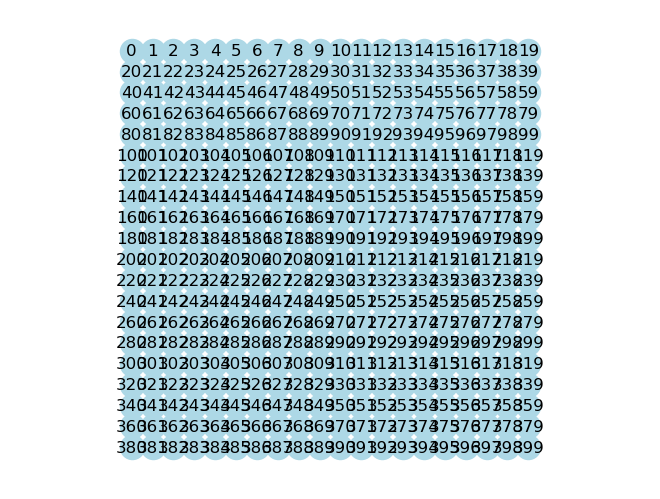

In [162]:
matrix = Matrix(20, 20)
adj_matrix, var_matrix = matrix.compute_matrices()
g = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
g.print_graph(grid_shape=(20,20), show_edge_labels=False)


In [164]:
general_comparison_run(matrix, 146, 300, eps=1e-2, max_iter=50)

====  STANDARD SOTA ====
Solving SOTA with Successive Approximations...
Convergence reached in 14 iterations with delta 1.3629798220549757e-05
Policy computed on 5830.9150 seconds
policy last column:
[  1  21   3   4   5   4   5  27  28  10   9  12  11  12  34  14  15  37
  19  39  40   1   2  43  23  24  25   7  29   9  10  51  31  32  14  15
  35  17  58  38  20  21  22  23  24  65  45  27  28  29  30  50  53  52
  34  54  57  37  57  58  61  60  42  62  44  66  46  68  48  89  50  70
  52  74  75  95  56  57  58  99  81  80  62 103  64  65  66  88  68  88
  89  71  72  94  93  75  95  98  78  79  80  81  82 102  84 106  86 106
  88  89 109 110 113  93  94 114  96  97  98  99 100 101 102 103 123 124
 146 126 108 128 131 151 112 153 114 115 116 136 118 119 141 121 141 142
 143 146  -1 146 147 129 149 152 153 133 153 135 136 158 157 139 140 160
 142 162 163 185 146 147 148 168 150 191 152 153 175 155 156 157 177 159
 181 161 162 184 164 184 166 167 168 190 189 192 172 194 214 175 176 1

In [165]:
general_comparison_run(matrix, 146, 500, eps=1e-2, max_iter=50)

====  STANDARD SOTA ====
Solving SOTA with Successive Approximations...
Convergence reached in 19 iterations with delta 0.0026592468802131286
Policy computed on 19027.9627 seconds
policy last column:
[  1  21   3   4   5   4   5  27  28  10   9  12  11  12  34  14  15  37
  19  39  40   1   2  43  23  24  25   7  29   9  10  51  31  32  14  15
  35  17  18  38  20  21  22  23  24  65  45  27  28  29  30  50  53  52
  34  54  57  37  57  79  61  60  42  62  44  66  46  68  48  89  50  70
  52  74  75  95  56  57  58  99  81  80  62 103  64  65  66  88  68  88
  89  71  72  94  93  75  95  98  78  79  80  81  82 102  84 106  86 106
  88  89 109 110 113  93  94 114  96  97  98  99 100 101 102 103 123 124
 146 126 108 128 131 151 112 153 114 115 116 136 118 119 141 121 141 142
 143 146  -1 146 147 129 149 152 153 133 153 135 136 158 157 139 140 160
 142 162 163 185 146 147 148 168 150 191 152 153 175 155 156 157 177 159
 181 161 162 184 164 184 166 167 168 190 189 192 172 194 214 175 176 1

In [169]:
general_comparison_run(matrix, 146, 700, eps=1e-2, max_iter=50)

====  STANDARD SOTA ====
Solving SOTA with Successive Approximations...
Computing SOTA..., iteration number: 1, delta=inf

KeyboardInterrupt: 

In [ ]:
general_comparison_run(matrix, 146, 900, eps=1e-2, max_iter=50)

In [ ]:
general_comparison_run(matrix, 146, 1100, eps=1e-2, max_iter=50)

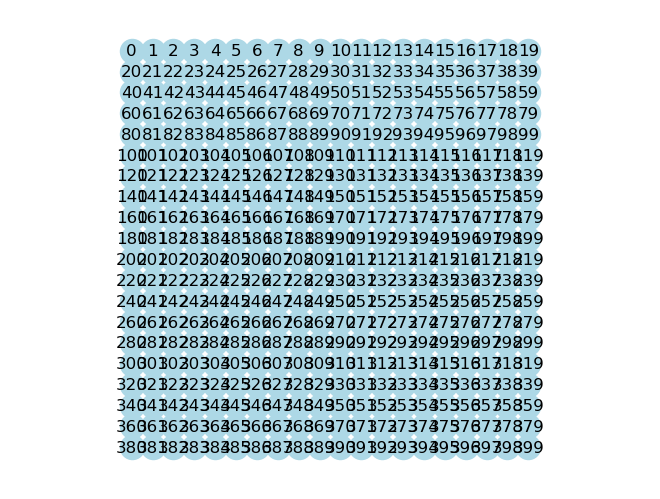

In [184]:
a, v = matrix.compute_matrices()
g = StochasticGraph(a,v)
g.print_graph(show_edge_labels=False)

In [185]:
Utils.save_object(g, "instances/graphs/20x20-1.pkl")

Object saved to instances/graphs/20x20-1.pkl


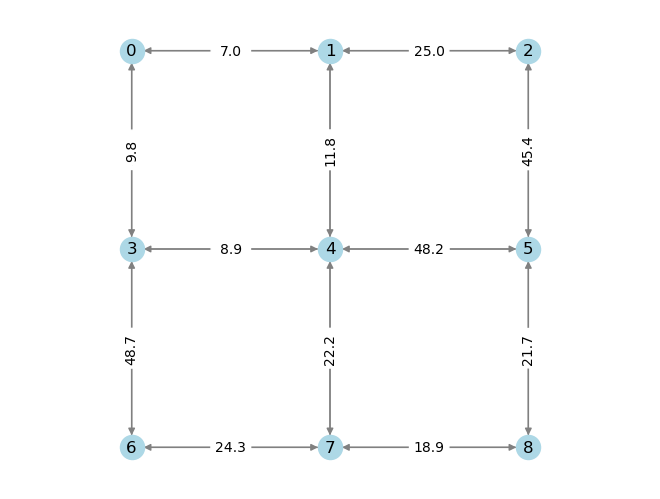

In [88]:
mc = Matrix(3,3)
mc.compute_matrices()
adj_matrix_c, var_matrix_c = mc.get_matrices()
gc = StochasticGraph(adj_matrix_c, var_matrix_c)
gc.print_graph()

In [146]:
sc = SingleIterationSOTASolver(gc, 4, 50)

In [147]:
sc.solve()
sc.get_sota_matrix()[:, -1]

array([3.62832994e-07, 6.93388808e-01, 1.30619040e-04, 9.83024048e-01,
       1.00000000e+00, 2.34673947e+00, 3.79584126e-07, 2.53261413e+00,
       1.14843581e+00])

In [148]:
sc.get_sota_matrix()[5,-1]

np.float64(2.3467394718950705)

In [130]:
sotamatrix = sc.initialize_matrix()
sc.compute_convolution(0,3,300, sotamatrix)

44
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
0


np.float64(0.0)

In [123]:
print(sc.get_sota_matrix()[:,-1])

[1.09346663 2.27221317 2.420911   1.41113977 1.         5.13387161
 1.87127017 5.54007979 2.48935166]


Computing reach values...
Reach values computed
Pruning nodes...
Pruned 45 nodes: {0, 2, 3, 8, 11, 13, 15, 17, 19, 20, 21, 22, 23, 27, 34, 36, 38, 40, 41, 42, 43, 44, 46, 47, 51, 53, 54, 61, 63, 65, 69, 70, 71, 73, 74, 76, 81, 82, 88, 90, 91, 93, 95, 97, 99}


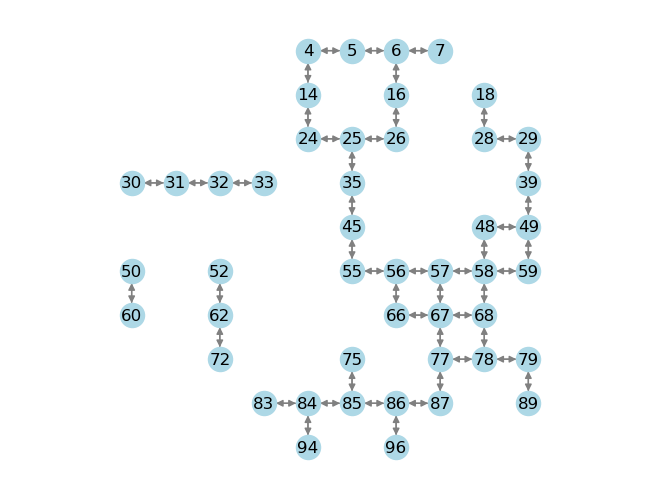

In [ ]:
adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
r = detReach(graph, d, 146)
r.reach_computation()
r.reach_pruning()
graph.print_graph(show_edge_labels=False)

Executing partition...
Partitioning of the graph in 5 regions executed in 0.0050 seconds!
Computing arcflags...
Arcflags computed!
Pruning edges...
[ArcFlags] Pruned 71 edges for destination 72 (region 2).


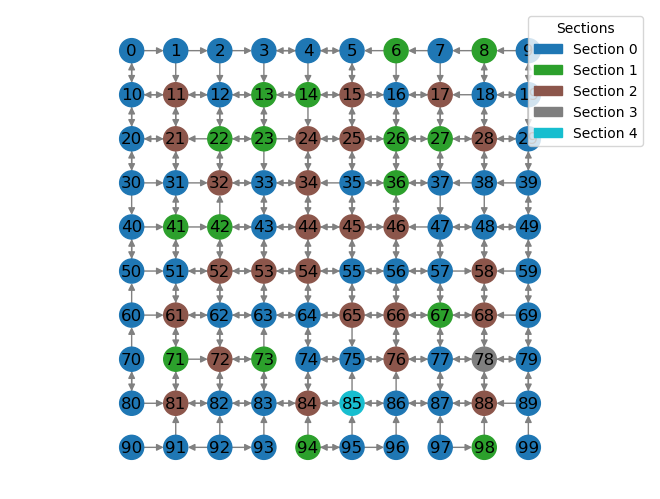

In [ ]:
adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, d, 146)

f.arcflags_computation()
f.arcflags_pruning()
f.print_graph_sections(show_edge_labels=False)

Results (in seconds):

|   |s-SOTA|si-SOTA|s-SOTA +detReach|si-SOTA +detReach|s-SOTA +detArcFlags|si-SOTA +detArcFlags|
|---|---|---|---|---|---|---|
|5x5 graph|25.7516|10.4251|4.2060 ⚠️|1.8326 ⚠️|14.5475|5.5268|

## Optimality of the solutions

Are the det-pruned solutions optimal? We will compare some of them

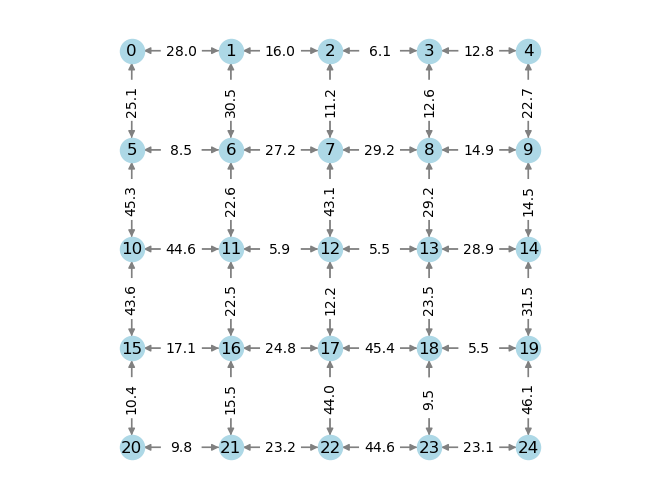

In [3]:
matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
graph.print_graph(grid_shape=(5,5))

In [9]:
def extract_path_from_policy(policy, start_node):
        """
        Extracts the optimal path for time-index watching the policy row.
        It stops if we get to destination, we get to a node -1.
        @return: list of nodes representing the optimal path from source to destination
        """
        path = [start_node]
        current = start_node

        max_steps = len(policy)*2
        steps = 0

        while True:
            # retrieving the next node
            next_node = policy[current]

            # stop if next = -1 or destination
            if next_node == -1:
                break

            path.append(int(next_node))
            current = next_node

            steps += 1

            if steps > max_steps:
                print("[Warning]A loop in the policy matrix was detected")
                break

        return path

In [45]:
#matrix = Matrix(5, 5, link_var_max=0.5)
#adj_matrix, var_matrix = matrix.compute_matrices()

adj_matrix, var_matrix = matrix.get_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
d = Dijkstra(adj_matrix)
f = detArcFlags(graph, 4, d, 20)
f.arcflags_computation()
f.arcflags_pruning()

s = StandardSOTASolver(graph, 20, 200)
s.solve()
policy = s.get_policy_matrix()[:,-1]

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0259 seconds!
Computing arcflags...
Arcflags computed!
Pruning edges...
[ArcFlags] Pruned 12 edges for destination 20 (region 1).


In [46]:
print(s.get_sota_matrix()[1,-1])
print(s.get_sota_matrix()[2,-1])
print(s.get_sota_matrix()[4,-1])
print(s.get_sota_matrix()[19,-1])

6.695003600262306e-06
1.7108241687354248e-07
5.518462600813787e-08
3.1377707756134825e-06


In [43]:
policy

array([ 5,  6,  7,  2,  3, 10,  5,  6, 13,  8, 15, 16, 11, 12, 13, 20, 21,
       22, 17, 24, -1, 20, 21, 22, 23])

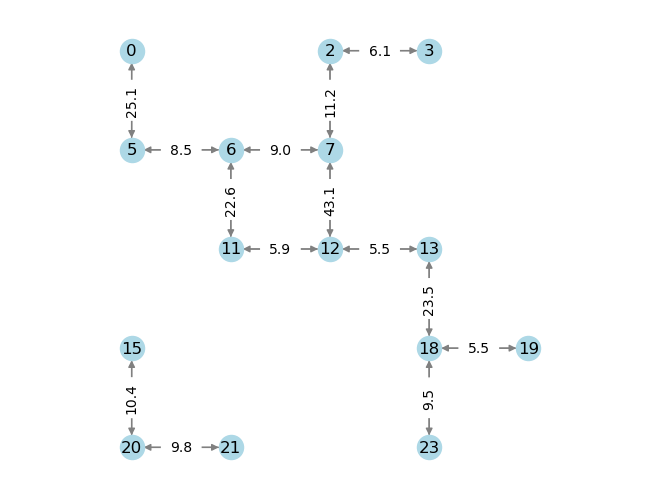

In [32]:
# printing the optimal path for [1,2,4,19]

path = extract_path_from_policy(policy, 19)
graph.print_graph(path, grid_shape=(5,5))

In [174]:
print(os.getcwd())

c:\SAMU\UNITO\MAGISTRALE\internship+tesi\codice\SOTA solver\notebook


In [179]:
m = Matrix(5,5)
a, v = m.compute_matrices()
g = StochasticGraph(a,v)

Utils.save_object(g, "instances/graphs/g.pkl")

Object saved to instances/graphs/g.pkl


In [182]:
n = Utils.load_object("instances/graphs/5x5-1.pkl")

Object loaded from instances/graphs/5x5-1.pkl


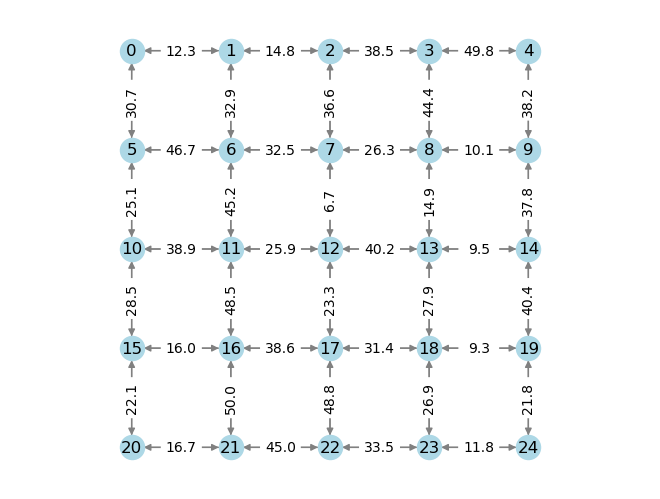

In [186]:
n.print_graph()